<a href="https://colab.research.google.com/github/anirban2003-web/Hubble-tension-literature-review/blob/main/notebooks/04_h0_posteriors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("h0_gaussian_posteriors_fig4_data.csv")
x = np.linspace(62, 80, 3000)
def gaussian(x, mu, sigma):
    return (
        np.exp(-0.5 * ((x - mu) / sigma) ** 2)
        / (sigma * np.sqrt(2 * np.pi))
    )
curves = {}

for _, row in df.iterrows():

    curves[row["probe"]] = gaussian(
        x,
        row["H0"],
        row["sigma"]
    )
planck_peak = np.max(curves["Planck 2018"])

for probe in curves:
    curves[probe] = curves[probe] / planck_peak





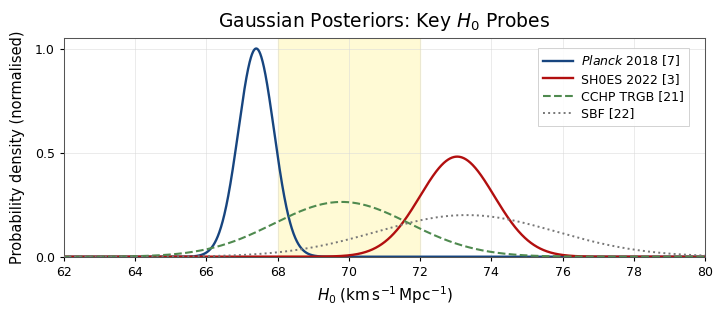

In [ ]:
fig, ax = plt.subplots(
    figsize=(8.12, 3.47),
    dpi=100
)
ax.axvspan(
    68,
    72,
    color="#fff7b3",
    alpha=0.55,
    zorder=0
)
ax.plot(
    x,
    curves["Planck 2018"],
    color="#17457f",
    linewidth=1.7,
    linestyle="-",
    label=r"$\it{Planck}$ 2018 [7]",
    zorder=3
)
ax.plot(
    x,
    curves["SH0ES 2022"],
    color="#b20f0f",
    linewidth=1.7,
    linestyle="-",
    label=r"SH0ES 2022 [3]",
    zorder=3
)

ax.plot(
    x,
    curves["CCHP TRGB"],
    color="#4f8a4f",
    linewidth=1.5,
    linestyle="--",
    label=r"CCHP TRGB [21]",
    zorder=3
)
ax.plot(
    x,
    curves["SBF"],
    color="#777777",
    linewidth=1.4,
    linestyle=":",
    label=r"SBF [22]",
    zorder=3
)

ax.set_xlim(62, 80)
ax.set_ylim(0, 1.05)

ax.set_xticks(
    np.arange(62, 81, 2)
)

ax.tick_params(
    axis="x",
    labelsize=9,
    direction="out",
    length=3
)

ax.set_yticks(
    [0, 0.5, 1.0]
)

ax.tick_params(
    axis="y",
    labelsize=9,
    direction="out",
    length=3
)

ax.set_xlabel(
    r"$H_0\;(\mathrm{km\,s^{-1}\,Mpc^{-1}})$",
    fontsize=11,
    labelpad=4
)

ax.set_ylabel(
    "Probability density (normalised)",
    fontsize=10.5,
    labelpad=7
)

ax.set_title(
    r"Gaussian Posteriors: Key $H_0$ Probes",
    fontsize=13.5,
    pad=8
)

ax.grid(
    True,
    which="major",
    axis="both",
    color="#d9d9d9",
    linewidth=0.55,
    alpha=0.65
)

ax.set_axisbelow(True)

legend = ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    fontsize=9,
    frameon=True,
    fancybox=False,
    framealpha=0.88,
    borderpad=0.45,
    handlelength=2.4,
    handletextpad=0.6,
    labelspacing=0.35
)

legend.get_frame().set_linewidth(0.7)
legend.get_frame().set_edgecolor("#cccccc")

for spine in ax.spines.values():
    spine.set_linewidth(0.75)
    spine.set_color("#555555")

plt.subplots_adjust(
    left=0.175,
    right=0.965,
    top=0.855,
    bottom=0.225
)

plt.savefig(
    "figure4_gaussian_H0_posteriors_exact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()